<a href="https://colab.research.google.com/github/2403A52058/ML_LAB_ASSIGNMENTS/blob/main/ML_assignmnet_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("data.csv")

# Drop unnecessary columns
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Encode target (M = 1, B = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(df.head())

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          

In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:54:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)
xgb_pred = xgb.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]

In [ ]:
# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

# ROC-AUC
print("RF ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("GB ROC-AUC:", roc_auc_score(y_test, gb_prob))
print("XGB ROC-AUC:", roc_auc_score(y_test, xgb_prob))

Random Forest Accuracy: 0.9649122807017544
Gradient Boosting Accuracy: 0.956140350877193
XGBoost Accuracy: 0.956140350877193
RF ROC-AUC: 0.995250573206682
GB ROC-AUC: 0.99475925319358
XGB ROC-AUC: 0.9908286930887651


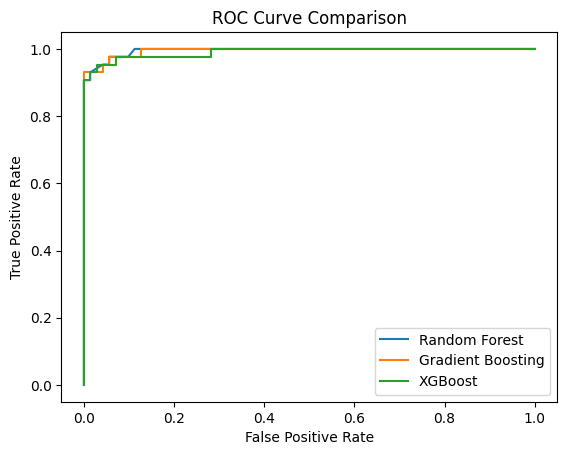

In [ ]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure()

plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()